In [1]:
import sys

In [2]:
sys.path.append('../')

In [3]:
import my_functions

In [4]:
for item in dir(my_functions):
    print(item)

ListedColormap
MakeData
PlotDecisionBoundary
RunClassifier
Scatterplot
__builtins__
__cached__
__doc__
__file__
__loader__
__name__
__package__
__spec__
make_classification
np
pd
plt
roc_auc_score
sns


In [5]:
from collections import Counter

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from imblearn.datasets import fetch_datasets

In [8]:
from imblearn.under_sampling import (
    RandomUnderSampler,
    CondensedNearestNeighbour,
    TomekLinks,
    OneSidedSelection,
    EditedNearestNeighbours,
    RepeatedEditedNearestNeighbours,
    AllKNN,
    NeighbourhoodCleaningRule,
    NearMiss,
    InstanceHardnessThreshold
)

In [34]:
undersampler_dict = {
    'random': RandomUnderSampler(
    sampling_strategy='auto',
    random_state=0,
    replacement=False,
),
    'cnn': CondensedNearestNeighbour(
    sampling_strategy='auto',
    random_state=0,
    n_neighbors=1,
    n_jobs=-1,
),
    'tomek': TomekLinks(sampling_strategy='auto', n_jobs=-1),
    'oss': OneSidedSelection(
    sampling_strategy='auto',
    random_state=0,
    n_neighbors=1,
    n_jobs=-1,
),
    'enn': EditedNearestNeighbours(
    sampling_strategy='auto',
    n_neighbors=3,
    kind_sel='all',
    n_jobs=-1,
),
    'renn': RepeatedEditedNearestNeighbours(
    sampling_strategy='auto',
    n_neighbors=3,
    max_iter=100,
    kind_sel='all',
    n_jobs=-1,
),
    'allknn': AllKNN(
    sampling_strategy='auto',
    n_neighbors=3,
    kind_sel='all',
    n_jobs=-1,
),
    'ncr': NeighbourhoodCleaningRule(
    sampling_strategy='auto',
    n_neighbors=3,
    threshold_cleaning=0.5,
    n_jobs=-1,
),
    'nm1': NearMiss(
    sampling_strategy='auto',
    version=1,
    n_neighbors=3,
    n_neighbors_ver3=3,
    n_jobs=-1,
),
    'nm2': NearMiss(
    sampling_strategy='auto',
    version=2,
    n_neighbors=3,
    n_neighbors_ver3=3,
    n_jobs=-1,
),
    'nm3': NearMiss(
    sampling_strategy='auto',
    version=3,
    n_neighbors=3,
    n_neighbors_ver3=3,
    n_jobs=-1,
),
    'iht': InstanceHardnessThreshold(
    estimator=LogisticRegression(random_state=0),
    sampling_strategy='auto',
    random_state=0,
    cv=3,
    n_jobs=-1,
)
}

In [35]:
undersampler_dict

{'random': RandomUnderSampler(random_state=0),
 'cnn': CondensedNearestNeighbour(n_jobs=-1, n_neighbors=1, random_state=0),
 'tomek': TomekLinks(n_jobs=-1),
 'oss': OneSidedSelection(n_jobs=-1, n_neighbors=1, random_state=0),
 'enn': EditedNearestNeighbours(n_jobs=-1),
 'renn': RepeatedEditedNearestNeighbours(n_jobs=-1),
 'allknn': AllKNN(n_jobs=-1),
 'ncr': NeighbourhoodCleaningRule(n_jobs=-1),
 'nm1': NearMiss(n_jobs=-1),
 'nm2': NearMiss(n_jobs=-1, version=2),
 'nm3': NearMiss(n_jobs=-1, version=3),
 'iht': InstanceHardnessThreshold(cv=3, estimator=LogisticRegression(random_state=0),
                           n_jobs=-1, random_state=0)}

In [30]:
for item in dir(imblearn.under_sampling):
    if 'Hard' in item:
        print(item)

InstanceHardnessThreshold


In [36]:
import imblearn.datasets

In [37]:
dir(imblearn.datasets)

['__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_imbalance',
 '_zenodo',
 'fetch_datasets',
 'make_imbalance']

In [38]:
dir(fetch_datasets)

['__annotations__',
 '__builtins__',
 '__call__',
 '__class__',
 '__closure__',
 '__code__',
 '__defaults__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__get__',
 '__getattribute__',
 '__globals__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__kwdefaults__',
 '__le__',
 '__lt__',
 '__module__',
 '__name__',
 '__ne__',
 '__new__',
 '__qualname__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__wrapped__',
 '_skl_parameter_constraints']

In [39]:
?fetch_datasets

Signature:
fetch_datasets(
    *,
    data_home=None,
    filter_data=None,
    download_if_missing=True,
    random_state=None,
    shuffle=False,
    verbose=False,
)
Docstring:
Load the benchmark datasets from Zenodo, downloading it if necessary.

.. versionadded:: 0.3

Parameters
----------
data_home : str, default=None
    Specify another download and cache folder for the datasets. By default
    all scikit-learn data is stored in '~/scikit_learn_data' subfolders.

filter_data : tuple of str/int, default=None
    A tuple containing the ID or the name of the datasets to be returned.
    Refer to the above table to get the ID and name of the datasets.

download_if_missing : bool, default=True
    If False, raise a IOError if the data is not locally available
    instead of trying to download the data from the source site.

random_state : int, RandomState instance or None, default=None
    Random state for shuffling the dataset.
    If int, random_state is the seed used by the random

In [41]:
fetch_datasets().keys()

odict_keys(['ecoli', 'optical_digits', 'satimage', 'pen_digits', 'abalone', 'sick_euthyroid', 'spectrometer', 'car_eval_34', 'isolet', 'us_crime', 'yeast_ml8', 'scene', 'libras_move', 'thyroid_sick', 'coil_2000', 'arrhythmia', 'solar_flare_m0', 'oil', 'car_eval_4', 'wine_quality', 'letter_img', 'yeast_me2', 'webpage', 'ozone_level', 'mammography', 'protein_homo', 'abalone_19'])

In [45]:
type(fetch_datasets)

function

In [46]:
dir(fetch_datasets())

['__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'clear',
 'copy',
 'fromkeys',
 'get',
 'items',
 'keys',
 'move_to_end',
 'pop',
 'popitem',
 'setdefault',
 'update',
 'values']

In [48]:
list(fetch_datasets().keys())

['ecoli',
 'optical_digits',
 'satimage',
 'pen_digits',
 'abalone',
 'sick_euthyroid',
 'spectrometer',
 'car_eval_34',
 'isolet',
 'us_crime',
 'yeast_ml8',
 'scene',
 'libras_move',
 'thyroid_sick',
 'coil_2000',
 'arrhythmia',
 'solar_flare_m0',
 'oil',
 'car_eval_4',
 'wine_quality',
 'letter_img',
 'yeast_me2',
 'webpage',
 'ozone_level',
 'mammography',
 'protein_homo',
 'abalone_19']

In [53]:
for item in fetch_datasets().keys():
    if 'eval' in item or 'ecoli' in item or 'thyroid' in item or 'arr' in item or 'ozone' in item:
        print(item)

ecoli
sick_euthyroid
car_eval_34
thyroid_sick
arrhythmia
car_eval_4
ozone_level


In [54]:
datasets_ls = [
    'car_eval_34',
    'ecoli',
    'thyroid_sick',
    'arrhythmia',
    'ozone_level'
]

In [62]:
for dataset in datasets_ls:
    data=fetch_datasets()[dataset]
    print(dataset)
    print(Counter(data.target))
    print()


car_eval_34
Counter({np.int64(-1): 1594, np.int64(1): 134})

ecoli
Counter({np.int64(-1): 301, np.int64(1): 35})

thyroid_sick
Counter({np.int64(-1): 3541, np.int64(1): 231})

arrhythmia
Counter({np.int64(-1): 427, np.int64(1): 25})

ozone_level
Counter({np.int64(-1): 2463, np.int64(1): 73})



In [58]:
data.DESCR

'ozone_level'

In [60]:
type(data.target)

numpy.ndarray

In [63]:
def run_randomForests(X_train, X_test, y_train, y_test):

    rf = RandomForestClassifier(
        n_estimators=100, random_state=0, max_depth=3, n_jobs=-1
    )

    rf.fit(X_train, y_train)

    print('Train set')
    pred = rf.predict_proba(X_train)[:,1]
    print('Random Forests roc-auc: {}'.format(roc_auc_score(y_train, pred)))

    print('Test set')
    pred = rf.predict_proba(X_test)[:,1]
    print('Random Forests roc-auc: {}'.format(roc_auc_score(y_test, pred)))

    return roc_auc_score(y_test, pred)

In [76]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
results_dict = {}
shapes_dict = {}

for dataset in datasets_ls:

    #Start a new dictionary per dataset
    results_dict[dataset] = {}
    shapes_dict[dataset] = {}

    print(dataset)

    data = fetch_datasets()[dataset]

    X_train, X_test, y_train, y_test = train_test_split(
        data.data,
        data.target,
        test_size=0.3,
        random_state=0
    )
    
    sc  = MinMaxScaler().fit(X_train)
    X_train = sc.transform(X_train)
    X_test = sc.transform(X_test)

    roc = run_randomForests(X_train, X_test, y_train, y_test)

    # print(roc)
    # print(len(X_train))

    results_dict[dataset]['full_data'] = roc
    shapes_dict[dataset]['full_data'] = len(X_train)

    print()

    for undersampler in undersampler_dict.keys():

        print(undersampler)

        X_resampled, y_resampled = undersampler_dict[undersampler].fit_resample(X_train, y_train)

        #Train the model and evaluate performance
        roc = run_randomForests(X_resampled, X_test, y_resampled, y_test)

        #storing results
        results_dict[dataset][undersampler] = roc
        shapes_dict[dataset][undersampler] = len(X_resampled)


    print()
    



car_eval_34
Train set
Random Forests roc-auc: 0.9768373993139862
Test set
Random Forests roc-auc: 0.9700734768853966

random
Train set
Random Forests roc-auc: 0.9973407330327205
Test set
Random Forests roc-auc: 0.988315134197367
cnn
Train set
Random Forests roc-auc: 0.9778952934955051
Test set
Random Forests roc-auc: 0.9912235942443107
tomek
Train set
Random Forests roc-auc: 0.9776413896079971
Test set
Random Forests roc-auc: 0.9704561689968364
oss
Train set
Random Forests roc-auc: 0.9792878547505728
Test set
Random Forests roc-auc: 0.9758138585569955
enn
Train set
Random Forests roc-auc: 0.9865152512617951
Test set
Random Forests roc-auc: 0.9645882232880906
renn
Train set
Random Forests roc-auc: 0.9866003273034807
Test set
Random Forests roc-auc: 0.9656597612001224
allknn
Train set
Random Forests roc-auc: 0.98005698005698
Test set
Random Forests roc-auc: 0.9658638636595571
ncr
Train set
Random Forests roc-auc: 0.9757761338830948
Test set
Random Forests roc-auc: 0.9585161751199103
nm1


In [87]:
for undersampler in undersampler_dict.keys():
    print(undersampler)

random
cnn
tomek
oss
enn
renn
allknn
ncr
nm1
nm2
nm3
iht


In [90]:
dir(results_dict)

['__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'clear',
 'copy',
 'fromkeys',
 'get',
 'items',
 'keys',
 'pop',
 'popitem',
 'setdefault',
 'update',
 'values']

In [89]:
results_dict

{'car_eval_34': {'full_data': np.float64(0.9700734768853966),
  'random': np.float64(0.988315134197367),
  'cnn': np.float64(0.9912235942443107),
  'tomek': np.float64(0.9704561689968364),
  'oss': np.float64(0.9758138585569955),
  'enn': np.float64(0.9645882232880906),
  'renn': np.float64(0.9656597612001224),
  'allknn': np.float64(0.9658638636595571),
  'ncr': np.float64(0.9585161751199103),
  'nm1': np.float64(0.9881110317379325),
  'nm2': np.float64(0.9293805490356158),
  'nm3': np.float64(0.9858148790692929),
  'iht': np.float64(0.9918359016226146)},
 'ecoli': {'full_data': np.float64(0.9541062801932366),
  'random': np.float64(0.9528985507246376),
  'cnn': np.float64(0.9685990338164251),
  'tomek': np.float64(0.9589371980676329),
  'oss': np.float64(0.8852657004830918),
  'enn': np.float64(0.9601449275362318),
  'renn': np.float64(0.9565217391304348),
  'allknn': np.float64(0.9565217391304347),
  'ncr': np.float64(0.9601449275362318),
  'nm1': np.float64(0.5072463768115942),
  '

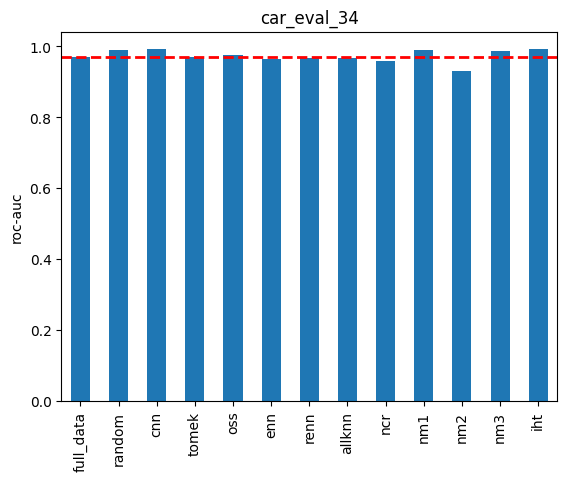

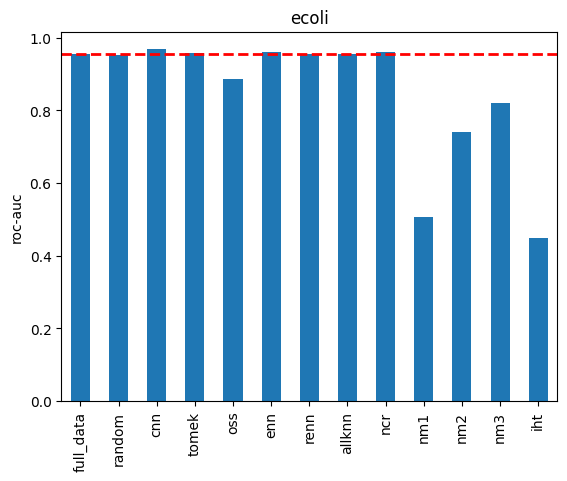

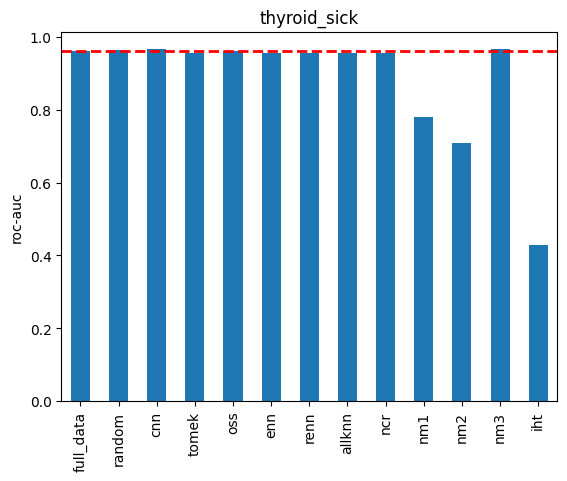

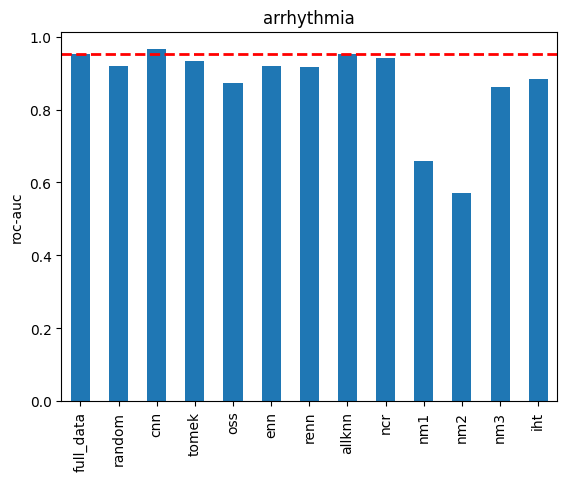

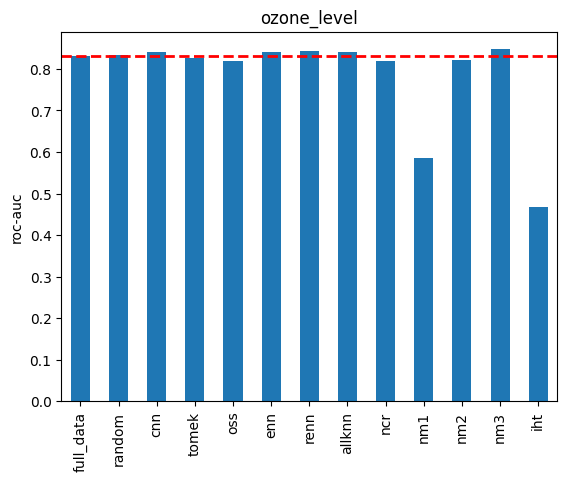

In [107]:
for dataset in datasets_ls:
    # print(results_dict[dataset].keys())
    pd.Series(results_dict[dataset]).plot.bar()
    plt.axhline(results_dict[dataset]['full_data'], c='r', linestyle='--', linewidth=2)
    plt.title(dataset)
    plt.ylabel('roc-auc')
    plt.show()
    

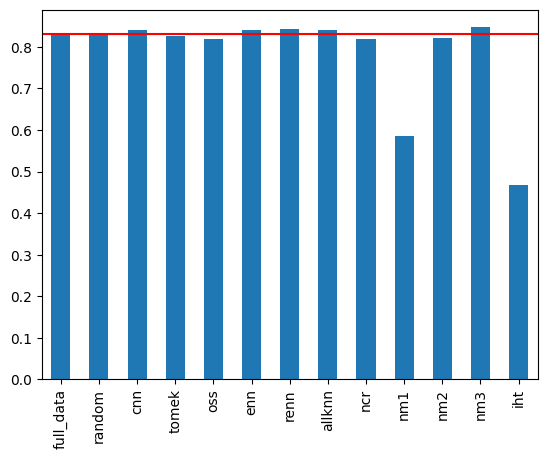

In [104]:
pd.Series(results_dict[dataset]).plot.bar()
plt.axhline(results_dict[dataset]['full_data'], c='r')

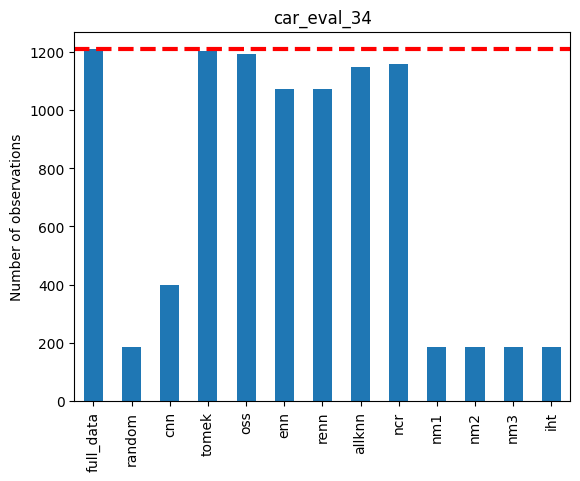

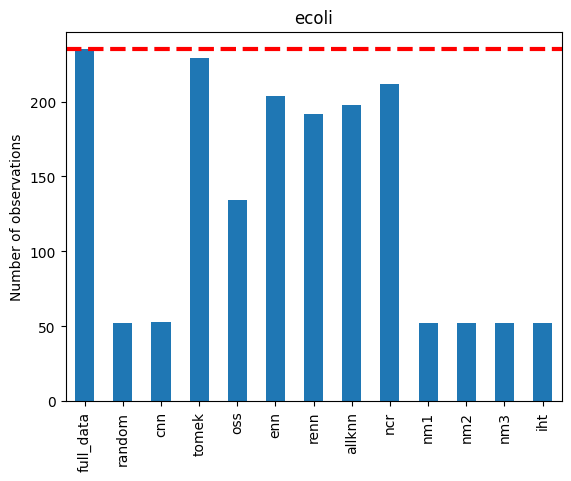

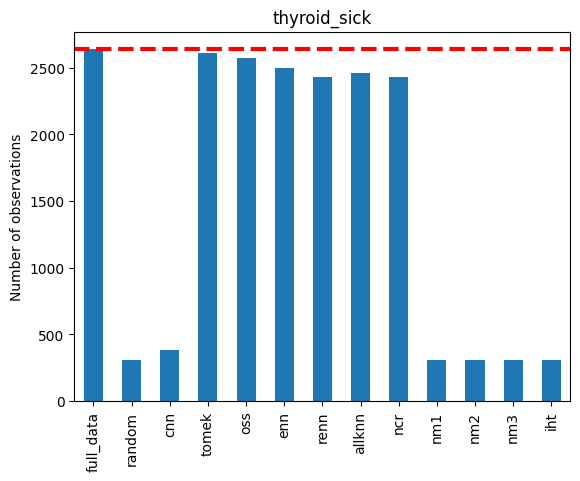

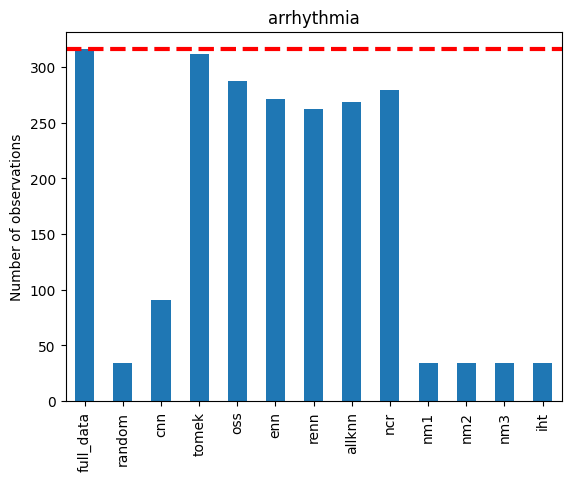

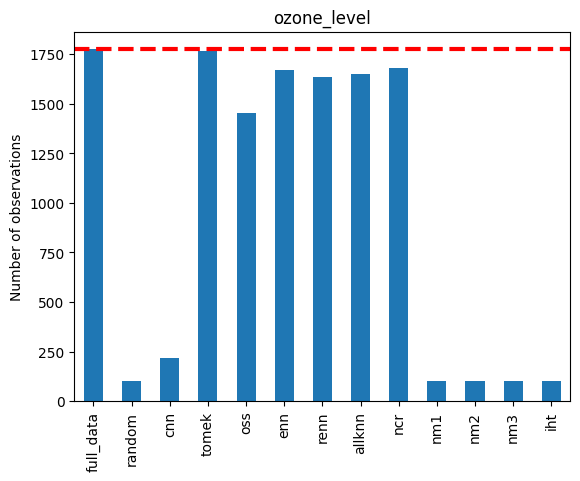

In [111]:
#Plotting the different finals shapes produced from different undersampling approaches
#Full data is the initial train set without any undersampling

for dataset in datasets_ls:
    pd.Series(shapes_dict[dataset]).plot.bar()
    plt.axhline(shapes_dict[dataset]['full_data'], c='r', linestyle='--', linewidth=3)
    plt.title(dataset)
    plt.ylabel('Number of observations')
    plt.show()

In [110]:
shapes_dict

{'car_eval_34': {'full_data': 1209,
  'random': 186,
  'cnn': 398,
  'tomek': 1202,
  'oss': 1191,
  'enn': 1073,
  'renn': 1072,
  'allknn': 1146,
  'ncr': 1157,
  'nm1': 186,
  'nm2': 186,
  'nm3': 186,
  'iht': 186},
 'ecoli': {'full_data': 235,
  'random': 52,
  'cnn': 53,
  'tomek': 229,
  'oss': 134,
  'enn': 204,
  'renn': 192,
  'allknn': 198,
  'ncr': 212,
  'nm1': 52,
  'nm2': 52,
  'nm3': 52,
  'iht': 52},
 'thyroid_sick': {'full_data': 2640,
  'random': 308,
  'cnn': 386,
  'tomek': 2609,
  'oss': 2574,
  'enn': 2495,
  'renn': 2434,
  'allknn': 2462,
  'ncr': 2432,
  'nm1': 308,
  'nm2': 308,
  'nm3': 308,
  'iht': 308},
 'arrhythmia': {'full_data': 316,
  'random': 34,
  'cnn': 91,
  'tomek': 312,
  'oss': 287,
  'enn': 271,
  'renn': 262,
  'allknn': 269,
  'ncr': 279,
  'nm1': 34,
  'nm2': 34,
  'nm3': 34,
  'iht': 34},
 'ozone_level': {'full_data': 1775,
  'random': 104,
  'cnn': 216,
  'tomek': 1764,
  'oss': 1451,
  'enn': 1668,
  'renn': 1635,
  'allknn': 1652,
  'n